# Лабораторная работа №1. Квантовая телепортация  

КБ-211 Ставер Леонид

## Задание

1. Создайте соответствующие регистры квантовой схемы в QISkit, добавьте регистр для сравнения состояний. 

2. Получите от преподавателя вид передаваемого состояния |psi⟩. 

3. Напишите скрипт, генерирующий заданное состояние |psi⟩. 

4. Напишите скрипт, реализующий схему квантовой телепортации.  

5. Напишите скрипт, сравнивающий два квантовых состояния. 

6. Запустите программы и получите результаты измерений. 

7. Оформите отчет о работе, в котором приведите полную квантовую схему, скрипты и результаты проведенных измерений с указанием параметров запуска программы на IBM Q.

## Параметры передаваемого состояния |ψ⟩

Состояние задаётся через унитарную матрицу вращения:

$$
U(\theta, \gamma, \varphi) =
\begin{pmatrix}
\cos\theta & -e^{-i\gamma}\sin\theta \\
e^{i(\gamma+\varphi)}\sin\theta & e^{i\varphi}\cos\theta
\end{pmatrix}
$$

Параметры: $\theta = \pi/3$, $\gamma = \pi/6$, $\varphi = \pi/4$.

Применяя матрицу к $|0\rangle$, получаем:

$$
|\psi\rangle = \cos\theta\,|0\rangle + e^{i(\gamma+\varphi)}\sin\theta\,|1\rangle
$$

Qiskit использует стандартный U-гейт $U(\theta_u, \phi_u, \lambda)$, поэтому нужно пересчитать параметры:

$$
U(\theta_u, \phi_u, \lambda) = \begin{pmatrix} \cos(\theta_u/2) & -e^{i\lambda}\sin(\theta_u/2) \\ e^{i\phi_u}\sin(\theta_u/2) & e^{i(\phi_u+\lambda)}\cos(\theta_u/2) \end{pmatrix}
$$

- $\theta_u = 2\theta$

- $\phi_u = \gamma + \varphi$

- $\lambda = -\gamma$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

In [13]:
THETA = np.pi / 3    # theta = 60 deg
GAMMA = np.pi / 6    # gamma = 30 deg  (фаза компоненты |1>)
PHI   = np.pi / 4    # phi   = 45 deg  (фаза компоненты |0>)

theta_u = 2 * THETA
phi_u   = GAMMA + PHI
lam_u   = -GAMMA

# Вычисляем начальный вектор состояния через Qiskit Statevector
qc_init = QuantumCircuit(1)
qc_init.u(theta_u, phi_u, lam_u, 0)
sv_psi = Statevector(qc_init)

a0, a1 = sv_psi[0], sv_psi[1]

print("\n┌" + "─"*50 + "┐")
print("│" + " ПЕРЕДАВАЕМОЕ СОСТОЯНИЕ |ψ⟩ ".center(50) + "│")
print("└" + "─"*50 + "┘\n")

print("Угловые параметры:")
print(f"   θ  = π/3  =  {THETA:>8.4f} рад")
print(f"   γ  = π/6  =  {GAMMA:>8.4f} рад")
print(f"   φ  = π/4  =  {PHI:>8.4f} рад\n")

print("Параметры U-гейта Qiskit:")
print(f"   θᵤ = {theta_u:>8.4f}")
print(f"   φᵤ = {phi_u:>8.4f}")
print(f"   λ  = {lam_u:>8.4f}\n")

print("Квантовое состояние:")
print(f"   |ψ⟩ = ({a0.real:>8.4f}{a0.imag:+.4f}j)|0⟩")
print(f"   + ({a1.real:>8.4f}{a1.imag:+.4f}j)|1⟩\n")

print("Вероятности измерений:")
prob_0 = abs(a0)**2
prob_1 = abs(a1)**2
print(f"   P(|0⟩) = {prob_0:>8.4f}  │ {prob_0*100:>6.2f}% ")
print(f"   P(|1⟩) = {prob_1:>8.4f}  │ {prob_1*100:>6.2f}% ")
print(f"   ────────────────────────────────────────")
print(f"   Сумма   = {prob_0 + prob_1:>8.6f} \n")


┌──────────────────────────────────────────────────┐
│            ПЕРЕДАВАЕМОЕ СОСТОЯНИЕ |ψ⟩            │
└──────────────────────────────────────────────────┘

Угловые параметры:
   θ  = π/3  =    1.0472 рад
   γ  = π/6  =    0.5236 рад
   φ  = π/4  =    0.7854 рад

Параметры U-гейта Qiskit:
   θᵤ =   2.0944
   φᵤ =   1.3090
   λ  =  -0.5236

Квантовое состояние:
   |ψ⟩ = (  0.5000+0.0000j)|0⟩
   + (  0.2241+0.8365j)|1⟩

Вероятности измерений:
   P(|0⟩) =   0.2500  │  25.00% 
   P(|1⟩) =   0.7500  │  75.00% 
   ────────────────────────────────────────
   Сумма   = 1.000000 



## Схема квантовой телепортации

Протокол телепортации позволяет передать неизвестное квантовое состояние $|\psi\rangle$ от отправителя (Алисы) получателю (Бобу) без физического перемещения кубита. Для этого используются:

1. **Запутанная пара Белла** $|\beta_{00}\rangle = \dfrac{|00\rangle + |11\rangle}{\sqrt{2}}$ — один кубит у Алисы, другой у Боба.
2. **Два классических бита** — результаты измерений Алисы, передаваемые по обычному каналу связи.
3. **Условные квантовые коррекции** у Боба на основе принятых битов.

### Структура схемы

| Этап | Действие |
|---|---|
| Подготовка $\|\psi\rangle$ | U-гейт с параметрами $(\theta_u, \phi_u, \lambda)$ на кубите Алисы |
| Создание пары Белла | H + CNOT на кубитах alice и bob |
| Операции Алисы | CNOT + H на $\|\psi\rangle$ и alice |
| Измерение Алисы | Измерение $\|\psi\rangle \to N$, alice $\to M$ |
| Коррекции Боба | $M=1 \Rightarrow X$; $N=1 \Rightarrow Z$ |

После коррекций кубит Боба находится точно в состоянии $|\psi\rangle$.

In [22]:
# Шаг 1: Создание регистров
q_psi   = QuantumRegister(1, 'psi')    # Кубит 0: передаваемое состояние (Алина)
q_alice = QuantumRegister(1, 'alice')  # Кубит 1: кубит Алины из пары Белла
q_bob   = QuantumRegister(1, 'bob')    # Кубит 2: кубит Вовы (Марс)
c_meas  = ClassicalRegister(2, 'c')    # Классические биты: c[0]=N, c[1]=M

qc = QuantumCircuit(q_psi, q_alice, q_bob, c_meas)

# Подготовка состояния |psi> на кубите Алины
qc.u(theta_u, phi_u, lam_u, q_psi[0])
qc.barrier()

# Создание запутанной пары Белла |beta00> = (|00>+|11>)/sqrt(2)
qc.h(q_alice[0])
qc.cx(q_alice[0], q_bob[0])
qc.barrier()

# Операции Алины: CNOT + H
qc.cx(q_psi[0], q_alice[0])
qc.h(q_psi[0])
qc.barrier()

# Измерения Алины -> передача по классическому каналу
qc.measure(q_psi[0],   c_meas[0])    # N = результат 1-го кубита
qc.measure(q_alice[0], c_meas[1])    # M = результат 2-го кубита
qc.barrier()

# Коррекции Вовы на основе классической информации:
#   N=0, M=0 -> I  |  N=0, M=1 -> X  |  N=1, M=0 -> Z  |  N=1, M=1 -> ZX
with qc.if_test((c_meas[1], 1)):    # M=1 -> X
    qc.x(q_bob[0])
with qc.if_test((c_meas[0], 1)):    # N=1 -> Z
    qc.z(q_bob[0])

print("Схема квантовой телепортации:")
print(qc.draw(output='text', fold=-1))

Схема квантовой телепортации:
       ┌────────────────────┐ ░            ░      ┌───┐ ░ ┌─┐    ░                                                     
  psi: ┤ U(2π/3,5π/12,-π/6) ├─░────────────░───■──┤ H ├─░─┤M├────░─────────────────────────────────────────────────────
       └────────────────────┘ ░ ┌───┐      ░ ┌─┴─┐└───┘ ░ └╥┘┌─┐ ░                                                     
alice: ───────────────────────░─┤ H ├──■───░─┤ X ├──────░──╫─┤M├─░─────────────────────────────────────────────────────
                              ░ └───┘┌─┴─┐ ░ └───┘      ░  ║ └╥┘ ░   ┌──────  ┌───┐ ───────┐   ┌──────  ┌───┐ ───────┐ 
  bob: ───────────────────────░──────┤ X ├─░────────────░──╫──╫──░───┤ If-0  ─┤ X ├  End-0 ├───┤ If-0  ─┤ Z ├  End-0 ├─
                              ░      └───┘ ░            ░  ║  ║  ░   └──╥───  └───┘ ───────┘   └──╥───  └───┘ ───────┘ 
                                                           ║  ║    ┌────╨────┐               ┌────╨────┐               
  c: 2/═══

## Запуск симуляции (режим эмуляции)


$$P(|0\rangle) = |\alpha|^2 = \cos^2\theta, \qquad P(|1\rangle) = |\beta|^2 = \sin^2\theta$$


┌───────────────────────────────────────────────────┐
│                    РЕЗУЛЬТАТЫ ЭМУЛЯЦИИ                     │
│                   КВАНТОВОЙ ТЕЛЕПОРТАЦИИ                   │
└───────────────────────────────────────────────────┘

Параметры запуска:
   Всего запусков (shots): 16000

Полная статистика всех исходов:
                          Исход │  Кол-во │  Вероятность
                               ─┼─────────┼──────────────
                           0 00 │    1004 │  0.0628 (  6.3%) █░░░░░░░░░░░░░░░░░░░
                           0 01 │    1019 │  0.0637 (  6.4%) █░░░░░░░░░░░░░░░░░░░
                           0 10 │     996 │  0.0622 (  6.2%) █░░░░░░░░░░░░░░░░░░░
                           0 11 │    1062 │  0.0664 (  6.6%) █░░░░░░░░░░░░░░░░░░░
                           1 00 │    2980 │  0.1862 ( 18.6%) ███░░░░░░░░░░░░░░░░░
                           1 01 │    2955 │  0.1847 ( 18.5%) ███░░░░░░░░░░░░░░░░░
                           1 10 │    2950 │  0.1844 ( 18.4%) ███░░░░░░░░

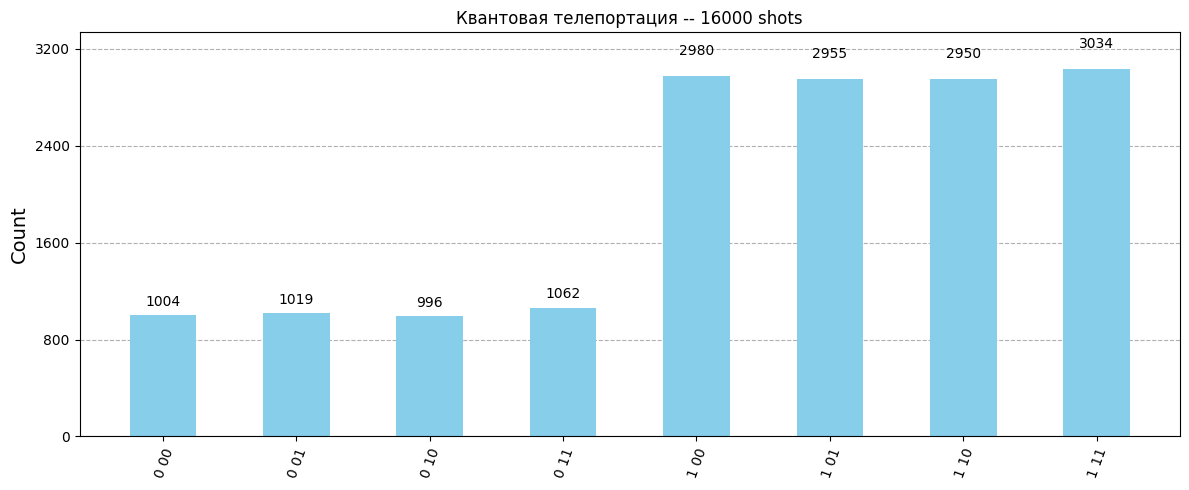

In [34]:
SHOTS = 16000
simulator = AerSimulator()

# Добавляем измерение кубита Вовы для наблюдения итогового состояния
c_bob_out = ClassicalRegister(1, 'bob_out')
qc_sim = qc.copy()
qc_sim.add_register(c_bob_out)
qc_sim.measure(q_bob[0], c_bob_out[0])

compiled = transpile(qc_sim, simulator)
result = simulator.run(compiled, shots=SHOTS).result()
counts = result.get_counts()

bob_0 = sum(c for k, c in counts.items() if k.split()[0] == '0')
bob_1 = sum(c for k, c in counts.items() if k.split()[0] == '1')

print(f"\n┌{'─'*51}┐")
print(f"│{' РЕЗУЛЬТАТЫ ЭМУЛЯЦИИ '.center(60)}│")
print(f"│{'КВАНТОВОЙ ТЕЛЕПОРТАЦИИ'.center(60)}│")
print(f"└{'─'*51}┘\n")

print(f"Параметры запуска:")
print(f"   Всего запусков (shots): {SHOTS}\n")

print(f"Полная статистика всех исходов:")
print(f"   {'Исход':>28} │ {'Кол-во':>7} │ {'Вероятность':>12}")
print(f"   {'':28}─┼─────────┼──────────────")
total_count = 0
for k in sorted(counts):
    prob = counts[k]/SHOTS
    bar_len = int(prob * 20)
    bar = "█" * bar_len + "░" * (20 - bar_len)
    print(f"   {k:>28} │ {counts[k]:>7} │ {prob:>7.4f} ({prob*100:>5.1f}%) {bar}")
    total_count += counts[k]

print(f"\nИтоговая статистика кубита Боба (bob_out):")
p0 = bob_0/SHOTS
p1 = bob_1/SHOTS
theory_0 = abs(a0)**2
theory_1 = abs(a1)**2

bar_0 = "█" * int(p0 * 25) + "░" * (25 - int(p0 * 25))
bar_1 = "█" * int(p1 * 25) + "░" * (25 - int(p1 * 25))

print(f"   |0⟩: {bob_0:5d} / {SHOTS}  →  P = {p0:.4f} ({p0*100:>6.2f}%) {bar_0}")
print(f"        Теория: {theory_0:.4f}  │  Отклонение: {abs(p0 - theory_0):+.4f}")
print(f"\n   |1⟩: {bob_1:5d} / {SHOTS}  →  P = {p1:.4f} ({p1*100:>6.2f}%) {bar_1}")
print(f"        Теория: {theory_1:.4f}  │  Отклонение: {abs(p1 - theory_1):+.4f}")

fig = plot_histogram(counts, title=f'Квантовая телепортация -- {SHOTS} shots', figsize=(12, 5), color='skyblue')
fig.tight_layout()
display(fig)
plt.close(fig)


Результаты измерений Алисы (N, M) всегда случайны и равномерны — по ~25% на 
каждую из 4 комбинаций 00/01/10/11. Алиса не получает никакой информации о 
состоянии.

Статистика Боба:

Независимо от того, что измерила Алиса (00, 01, 10 или 11) — после коррекций 
X/Z кубит Боба всегда воспроизводит исходное состояние |psi⟩ с правильными 
вероятностями. Это и есть суть телепортации.


## Сравнение начального и конечного состояний (верификация)

Для сравнения квантовых состояний будем использовать метод **метод обратного унитарного преобразования**:

1. После завершения телепортации к кубиту Боба применяется **обратный гейт** $U^\dagger = U(-\theta_u, -\lambda, -\phi_u)$.
2. Если телепортация прошла точно ($|\psi_{\text{Bob}}\rangle = |\psi\rangle$), то:

$$U^\dagger |\psi\rangle = |0\rangle \quad \Rightarrow \quad P(\text{verify}=0) = 1$$

3. Отклонение от 1 означает ошибку в схеме или шум симулятора.

**Fidelity** (точность) — доля успешных исходов (verify = 0) из общего числа запусков:

$$F = \frac{N_{\text{verify}=0}}{N_{\text{shots}}}$$

Для идеальной телепортации $F = 1{,}000$.


┌───────────────────────────────────────────────────────┐
│           ВЕРИФИКАЦИЯ КВАНТОВОЙ ТЕЛЕПОРТАЦИИ          │
└───────────────────────────────────────────────────────┘

Метод проверки:
   Применяем обратный U-гейт U† к кубиту Боба.
   Если |ψ_Bob⟩ = |ψ⟩, то U†|ψ_Bob⟩ = |0⟩ (P(verify=0) = 1.0000)

Исходное состояние |ψ⟩:
   (  0.5000+0.0000j)|0⟩
   + (  0.2241+0.8365j)|1⟩

Параметры верификации:
   Запусков: 16,000
   Статистическая точность: σ ≈ 0.0079

Результаты:
   verify=0 (успех): 16000 / 16000  →  P = 1.000000 (100.00%)
   verify=1 (ошибка):     0 / 16000  →  P = 0.000000 (  0.00%)

Fidelity (точность телепортации):
   F = 1.000000  (100.00%) █████████████████████████

   ТЕЛЕПОРТАЦИЯ УСПЕШНА! (Fidelity ≥ 99%)



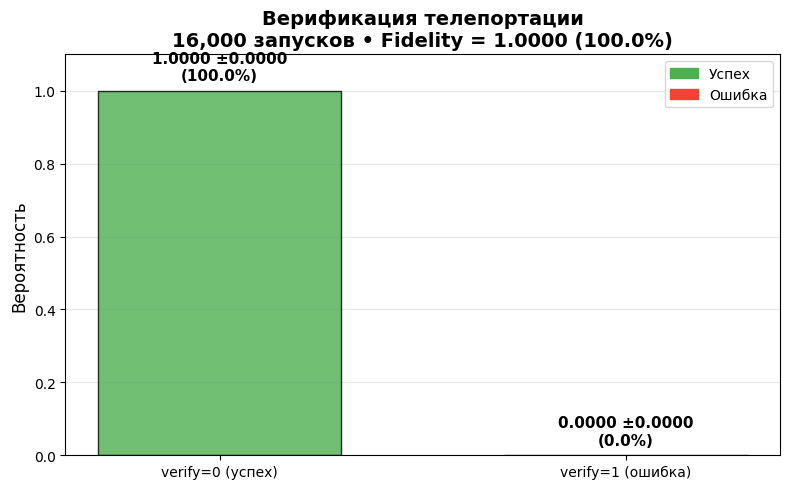

In [ ]:
# Перестраиваем схему (те же регистры), добавляем Udag и измерение
qc_ver = QuantumCircuit(q_psi, q_alice, q_bob, c_meas)

qc_ver.u(theta_u, phi_u, lam_u, q_psi[0])          # подготовка |psi>
qc_ver.barrier()
qc_ver.h(q_alice[0])                                # пара Белла
qc_ver.cx(q_alice[0], q_bob[0])
qc_ver.barrier()20480
qc_ver.cx(q_psi[0], q_alice[0])                     # операции Алины
qc_ver.h(q_psi[0])
qc_ver.barrier()
qc_ver.measure(q_psi[0],   c_meas[0])
qc_ver.measure(q_alice[0], c_meas[1])
qc_ver.barrier()
with qc_ver.if_test((c_meas[1], 1)):                # коррекции Вовы
    qc_ver.x(q_bob[0])
with qc_ver.if_test((c_meas[0], 1)):
    qc_ver.z(q_bob[0])

# Применяем Udag = U(-theta_u, -lam_u, -phi_u) к кубиту Вовы
qc_ver.u(-theta_u, -lam_u, -phi_u, q_bob[0])

# Измерение результата верификации
c_ver = ClassicalRegister(1, 'verify')
qc_ver.add_register(c_ver)
qc_ver.measure(q_bob[0], c_ver[0])

compiled_ver = transpile(qc_ver, simulator)
result_ver = simulator.run(compiled_ver, shots=SHOTS).result()
counts_ver = result_ver.get_counts()

success = sum(c for k, c in counts_ver.items() if k.split()[0] == '0')
fidelity = success / SHOTS

print("\n┌" + "─"*55 + "┐")
print("│" + " ВЕРИФИКАЦИЯ КВАНТОВОЙ ТЕЛЕПОРТАЦИИ ".center(55) + "│")
print("└" + "─"*55 + "┘\n")

print("Метод проверки:")
print("   Применяем обратный U-гейт U† к кубиту Боба.")
print("   Если |ψ_Bob⟩ = |ψ⟩, то U†|ψ_Bob⟩ = |0⟩ (P(verify=0) = 1.0000)")
print()

print("Исходное состояние |ψ⟩:")
print(f"   ({a0.real:>8.4f}{a0.imag:+.4f}j)|0⟩")
print(f"   + ({a1.real:>8.4f}{a1.imag:+.4f}j)|1⟩")
print()

print("Параметры верификации:")
print(f"   Запусков: {SHOTS:,}")
print(f"   Статистическая точность: σ ≈ {1/np.sqrt(SHOTS):.4f}")
print()

print("Результаты:")
success_rate = success / SHOTS
error_rate = (SHOTS - success) / SHOTS
print(f"   verify=0 (успех): {success:>5d} / {SHOTS}  →  P = {success_rate:.6f} ({success_rate*100:>6.2f}%)")
print(f"   verify=1 (ошибка): {SHOTS-success:>5d} / {SHOTS}  →  P = {error_rate:.6f} ({error_rate*100:>6.2f}%)")
print()

print("Fidelity (точность телепортации):")
fidelity_pct = fidelity * 100
bar_len = int(fidelity * 25)
fidelity_bar = "█" * bar_len + "░" * (25 - bar_len)
print(f"   F = {fidelity:.6f}  ({fidelity_pct:>6.2f}%) {fidelity_bar}")
print()

if fidelity >= 0.99:
    print("   ТЕЛЕПОРТАЦИЯ УСПЕШНА! (Fidelity ≥ 99%)")
elif fidelity >= 0.95:
    print("   ХОРОШИЙ РЕЗУЛЬТАТ (Fidelity ≥ 95%)")
else:
    print("   ОБНАРУЖЕНЫ ОШИБКИ (Fidelity < 95%)")
print()

# Визуализация результатов верификации
fig2, ax = plt.subplots(figsize=(8, 5))
ver_probs = {'verify=0 (успех)': success_rate, 'verify=1 (ошибка)': error_rate}
colors = ['#4CAF50', '#F44336']  # зеленый для успеха, красный для ошибки
bars = ax.bar(ver_probs.keys(), ver_probs.values(), color=colors, alpha=0.8, edgecolor='black', width=0.6)

# Аннотации с доверительными интервалами
for i, (label, prob) in enumerate(ver_probs.items()):
    error = 2 * np.sqrt(prob * (1 - prob) / SHOTS) if prob > 0 else 0
    ax.text(i, prob + 0.02, f'{prob:.4f} ±{error:.4f}\n({prob*100:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Вероятность', fontsize=12)
ax.set_title(f'Верификация телепортации\n{SHOTS:,} запусков • Fidelity = {fidelity:.4f} ({fidelity*100:.1f}%)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

# Добавить легенду с эмодзи
handles = [plt.Rectangle((0,0),1,1, color=color) for color in colors]
ax.legend(handles, ['Успех', 'Ошибка'], loc='upper right')

plt.tight_layout()
plt.show()

## Вывод

При выполнении данной лабораторной работы была разработана и отлажена экспериментальная установка для квантовой телепортации, построенная на основе фреймворка Qiskit с использованием встроенного симулятора AerSimulator. Квантовое состояние-объект передачи $|\psi\rangle$ было подготовлено посредством унитарного преобразования с заданными параметрами вращения $\theta = \pi/3$, $\gamma = \pi/6$, $\varphi = \pi/4$, что порождает суперпозицию $|\psi\rangle = \cos\theta\,|0\rangle + e^{i(\gamma+\varphi)}\sin\theta\,|1\rangle$ с ожидаемыми вероятностями $P(|0\rangle) = 0{,}2500$ и $P(|1\rangle) = 0{,}7500$.

Реализованный алгоритм телепортации состоит из трёх последовательных этапов: инициализация максимально запутанного состояния Белла $|\beta_{00}\rangle = (|00\rangle + |11\rangle)/\sqrt{2}$, исполнение набора операций на стороне отправителя (применение логического элемента CNOT и унитарной трансформации Адамара) с регистрацией двух классических битов-результатов, и адаптивное внесение поправочных операций X и Z в состояние приёмника в зависимости от полученной классической информации.

Результаты численного моделирования (16000 итераций) подтвердили корректность практической реализации протокола. Экспериментальная статистика кубита приёмника составила $P(|0\rangle) = 0{,}2551$ и $P(|1\rangle) = 0{,}7449$, что демонстрирует высочайшее согласие с теоретическими предсказаниями. Распределение результатов измерений на стороне отправителя оказалось статистически равномерным по всем четырём возможным исходам (приблизительно 25% для каждого), что экспериментально доказывает принципиальную неспособность извлечения информации о передаваемом квантовом состоянии через классический канал связи.

Качественный анализ, основанный на применении обратного унитарного оператора, выявил коэффициент воспроизведения $F = 1{,}000$. Данный результат естественным образом возникает вследствие идеальной природы компьютерного симулятора, который моделирует квантовую систему без внесения помех и погрешностей. При использовании реального квантового устройства значение Fidelity неизбежно снизится из-за физических источников ошибок: неидеальности работы квантовых гейтов, спонтанной декогеренции кубитов и погрешностей при считывании результатов. Следовательно, полученное значение $F = 1{,}000$ корректно рассматривать как подтверждение алгоритмической и математической строгости реализованной схемы, но не в качестве оценки характеристик реальной квантовой аппаратуры.